Installation of libraries

In [ ]:
!pip install scikit-image opencv-python-headless matplotlib scikit-learn pandas pillow

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from skimage import io, color
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load images and CSV

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Team Dattel/Computational Social Media Analysis/Preprocessing Data/combined_clean_messy_new.csv")
df.head()

,pin_id,title,description,domain,board,created_at,image_url,category
0,21251429487397507,NaN,NaN,Uploaded by user,Lifestyle,"Wed, 22 Oct 2025 07:20:25 +0000",https://i.pinimg.com/originals/09/e9/a3/09e9a3...,clean_girl_
1,281543725716857,NaN,NaN,Uploaded by user,aesthetic inspo,"Sun, 22 Jun 2025 21:00:24 +0000",https://i.pinimg.com/originals/e2/99/49/e29949...,clean_girl_
2,Ad4Jj0M0b2zAQG3867WSlOAYg40oMTT84o3eKc5sz0NwHb...,syoss Intense Keratin,Entdecke jetzt die syoss Intense Keratin Pfleg...,syoss.de,Ad-only Pins,"Thu, 08 Jan 2026 13:07:16 +0000",https://i.pinimg.com/originals/49/2c/90/492c90...,clean_girl_
3,AU2ScxmiEIV1SpLi8wNppJ4U0vFgnZM3dtKi96S7qDYJE4...,Dein neuer Long-Hair Fav!✨,"Langes Haar? Hol dir die Pflege, die es verdie...",dm.de,Nur als Anzeigen gedachte Pins,"Thu, 20 Nov 2025 17:54:23 +0000",https://i.pinimg.com/originals/30/43/82/304382...,clean_girl_
4,119556565105668720,NaN,NaN,Uploaded by user,2026 vision board,"Fri, 02 Jan 2026 05:46:44 +0000",https://i.pinimg.com/originals/e5/fb/d9/e5fbd9...,clean_girl_


In [ ]:
IMAGE_DIR = "/content/drive/MyDrive/Team Dattel/Computational Social Media Analysis/Preprocessing Data/Images"
df["full_path"] = df["image_url"]

Convert HEIC images

In [ ]:
# Count HEIC images
heic_images = df[df["image_url"].str.lower().str.endswith(".heic")]["image_url"].tolist()

print(f"Number of HEIC images: {len(heic_images)}")
print(f"Number of non HEIC images: {len(df) - len(heic_images)}")

In [ ]:
!apt-get install -y libheif-examples
!pip install pillow-heif

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  libheif-examples
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 35.2 kB of archives.
After this operation, 137 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libheif-examples amd64 1.12.0-2build1 [35.2 kB]
Fetched 35.2 kB in 0s (73.8 kB/s)
Selecting previously unselected package libheif-examples.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../libheif-examples_1.12.0-2build1_amd64.deb ...
Unpacking libheif-examples (1.12.0-2build1) ...
Setting up libheif-examples (1.12.0-2build1) ...
Processing triggers for man-db (2.10.2-1) ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 71.3 MB/s eta 0:00:00


In [ ]:
from pillow_heif import register_heif_opener
register_heif_opener()

In [ ]:
import requests
import os
from PIL import Image

DOWNLOAD_DIR = "/content/heic_downloads"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

local_heic_paths = []

for url in heic_images:
    filename = os.path.basename(url)
    local_path = os.path.join(DOWNLOAD_DIR, filename)

    try:
        r = requests.get(url, stream=True)
        if r.status_code == 200:
            with open(local_path, "wb") as f:
                f.write(r.content)
            local_heic_paths.append(local_path)
        else:
            print("Download failed:", url)
    except Exception as e:
        print("Error downloading:", url, e)


Extract dominant colors

In [ ]:
def extract_lab_palette(image_path, n_colors=5):
    try:
        img = io.imread(image_path)

        # If PNG with alpha → remove alpha
        if img.shape[-1] == 4:
            img = img[..., :3]

        # Convert to CIELAB
        lab = color.rgb2lab(img)

        # Reshape pixels
        pixels = lab.reshape(-1, 3)

        # KMeans
        kmeans = KMeans(n_clusters=n_colors, random_state=42)
        kmeans.fit(pixels)

        # Cluster centers (dominant colors)
        colors_lab = kmeans.cluster_centers_

        # Share per cluster
        labels = kmeans.labels_
        counts = np.bincount(labels)
        proportions = counts / len(labels)

        return colors_lab, proportions

    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None, None

Convert LAB to RGB for visualization

In [ ]:
def lab_to_rgb(lab_array):
    lab_array = np.array(lab_array).reshape(1, 1, 3)
    rgb = color.lab2rgb(lab_array)
    return rgb.reshape(3,)

Calculate palette for all pins

In [ ]:
all_palettes = []

for idx, row in df.iterrows():
    colors_lab, proportions = extract_lab_palette(row["full_path"], n_colors=5)
    if colors_lab is not None:
        all_palettes.append({
            "filename": row["pin_id"],
            "trend": row["category"],
            "colors_lab": colors_lab,
            "proportions": proportions
        })
    if idx % 100 == 0:
        print(f"Done: {idx}/{len(df)}")

print(f"Finished: {len(all_palettes)} of {len(df)} pins successfully processed.")

Done: 0/600
Done: 100/600
Done: 200/600
Done: 300/600
Done: 400/600
Done: 500/600
Finished: 600 of 600 pins successfully processed.


Example for visualization for one pin

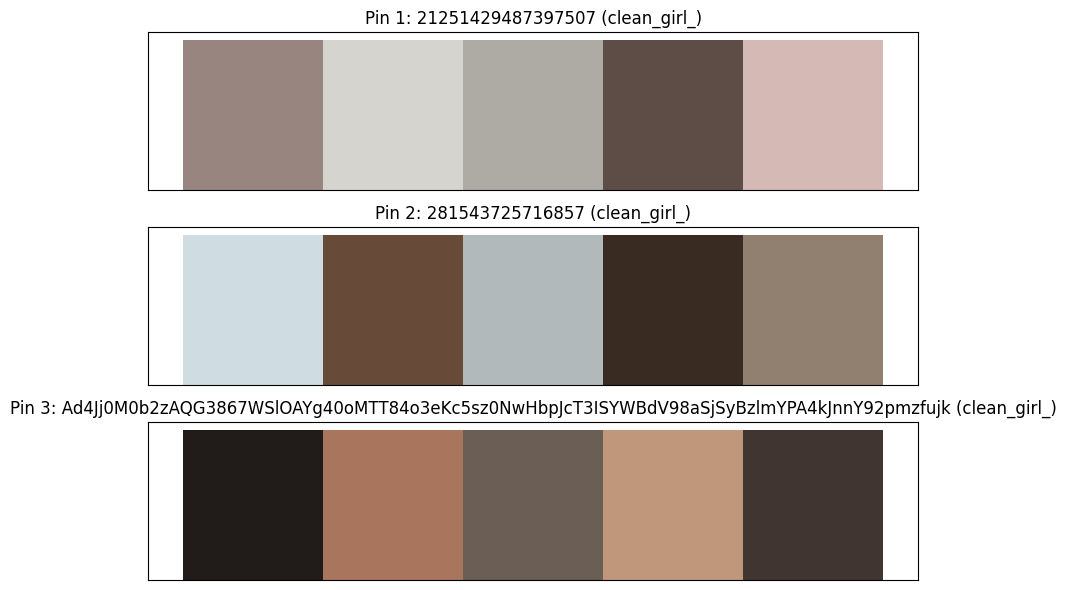

In [ ]:
n_examples = 3

fig, axes = plt.subplots(n_examples, 1, figsize=(8, 2 * n_examples))

for i in range(n_examples):
    example_path = df["full_path"].iloc[i]
    colors_lab, proportions = extract_lab_palette(example_path, n_colors=5)

    if colors_lab is not None:
        for j, (lab_col, prop) in enumerate(zip(colors_lab, proportions)):
            rgb = lab_to_rgb(lab_col)
            axes[i].bar(j, 1, color=rgb, width=1)

        axes[i].set_xticks([])
        axes[i].set_yticks([])
        axes[i].set_title(f"Pin {i+1}: {df['pin_id'].iloc[i]} ({df['category'].iloc[i]})")

plt.tight_layout()
plt.show()

Save all results in a DataFrame

In [ ]:
def rgb_to_hex(rgb):
    rgb = np.clip(rgb * 255, 0, 255).astype(int)
    return "#{:02x}{:02x}{:02x}".format(rgb[0], rgb[1], rgb[2])

In [ ]:
records = []

for item in all_palettes:
    for i, (lab_col, prop) in enumerate(zip(item["colors_lab"], item["proportions"])):
        rgb = lab_to_rgb(lab_col)
        records.append({
            "pin_id": item["filename"],
            "trend": item["trend"],
            "cluster": i,
            "L": lab_col[0],
            "a": lab_col[1],
            "b": lab_col[2],
            "proportion": prop,
            "hex": rgb_to_hex(rgb)
        })

palette_df = pd.DataFrame(records)
print(f"Einträge gesamt: {len(palette_df)}")
print(palette_df.head(10))

Einträge gesamt: 3000
              pin_id        trend  cluster          L          a          b  \
0  21251429487397507  clean_girl_        0  56.995589   6.218912   5.544803   
1  21251429487397507  clean_girl_        1  84.722818  -0.438035   3.026476   
2  21251429487397507  clean_girl_        2  69.838406  -0.603004   4.164615   
3  21251429487397507  clean_girl_        3  33.944245   7.156342   5.491699   
4  21251429487397507  clean_girl_        4  77.308397   9.122984   5.994509   
5    281543725716857  clean_girl_        0  86.942327  -3.381843  -3.793141   
6    281543725716857  clean_girl_        1  34.089247  10.369612  15.466467   
7    281543725716857  clean_girl_        2  74.661314  -1.919307  -1.789182   
8    281543725716857  clean_girl_        3  18.890252   4.413265   9.143594   
9    281543725716857  clean_girl_        4  54.460948   4.271618  10.634055   

   proportion      hex  
0    0.268365  #97847f  
1    0.143981  #d5d3cd  
2    0.324445  #acaaa3  
3    0.0

In [ ]:
# HEX per cluster in wide format (hex_0 - hex_4)
hex_wide = palette_df.pivot_table(
    index="pin_id",
    columns="cluster",
    values="hex",
    aggfunc="first"
)
hex_wide.columns = [f"hex_{i+1}" for i in hex_wide.columns]
hex_wide = hex_wide.reset_index()

# LAB + proportion in wide-format
lab_wide = palette_df.pivot_table(
    index="pin_id",
    columns="cluster",
    values=["L", "a", "b", "proportion"],
    aggfunc="first"
)
lab_wide.columns = [f"{val}_{cluster}" for val, cluster in lab_wide.columns]
lab_wide = lab_wide.reset_index()

# Combine with original CSV
original_df = pd.read_csv("/content/drive/MyDrive/Team Dattel/Computational Social Media Analysis/Preprocessing Data/combined_clean_messy_new.csv")

df_merged = original_df \
    .merge(lab_wide, on="pin_id", how="left") \
    .merge(hex_wide, on="pin_id", how="left")

# Save
df_merged.to_csv("/content/drive/MyDrive/Team Dattel/Computational Social Media Analysis/Preprocessing Data/combined_colors.csv", index=False)

print(f"Gespeichert mit {len(df_merged.columns)} Spalten")
print(df_merged.head())

Gespeichert mit 33 Spalten
                                              pin_id  \
0                                  21251429487397507   
1                                    281543725716857   
2  Ad4Jj0M0b2zAQG3867WSlOAYg40oMTT84o3eKc5sz0NwHb...   
3  AU2ScxmiEIV1SpLi8wNppJ4U0vFgnZM3dtKi96S7qDYJE4...   
4                                 119556565105668720   

                        title  \
0                         NaN   
1                         NaN   
2       syoss Intense Keratin   
3  Dein neuer Long-Hair Fav!✨   
4                         NaN   

                                         description            domain  \
0                                                NaN  Uploaded by user   
1                                                NaN  Uploaded by user   
2  Entdecke jetzt die syoss Intense Keratin Pfleg...          syoss.de   
3  Langes Haar? Hol dir die Pflege, die es verdie...             dm.de   
4                                                NaN  Uploaded by u

Comparison of trends

In [ ]:
trend_means = palette_df.groupby("trend")[["L", "a", "b"]].mean()
trend_means

,L,a,b
trend,,,
clean_girl_,53.687679,4.573816,8.776948
messy_girl_,44.563030,5.072701,10.355442


Visualization of trend palettes

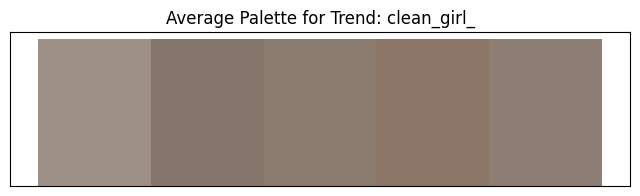

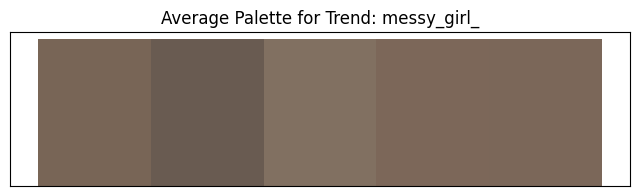

In [ ]:
def plot_trend_palette(trend_name):
    subset = palette_df[palette_df["trend"] == trend_name]
    mean_colors = subset.groupby("cluster")[["L", "a", "b"]].mean().values

    plt.figure(figsize=(8, 2))
    for i, lab_col in enumerate(mean_colors):
        rgb = lab_to_rgb(lab_col)
        plt.bar(i, 1, color=rgb, width=1)
    plt.xticks([])
    plt.yticks([])
    plt.title(f"Average Palette for Trend: {trend_name}")
    plt.show()

plot_trend_palette("clean_girl_")
plot_trend_palette("messy_girl_")

CIELAB-Histogram per trend

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_lab_histograms_compared(palette_df):
    trends = ["clean_girl_", "messy_girl_"]
    channels = [("L", "goldenrod"), ("a", "crimson"), ("b", "teal")]

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))

    for row_idx, (channel, color) in enumerate(channels):
        for col_idx, trend in enumerate(trends):
            subset = palette_df[palette_df["trend"] == trend]

            sns.histplot(
                subset[channel],
                bins=30,
                kde=True,
                ax=axes[row_idx][col_idx],
                color=color
            )
            axes[row_idx][col_idx].set_title(f"{channel}‑Histogramm ({trend})")
            axes[row_idx][col_idx].set_xlabel(channel)
            axes[row_idx][col_idx].set_ylabel("Anzahl")

    plt.suptitle("CIELAB‑Verteilung: Clean Girl vs. Messy Girl",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

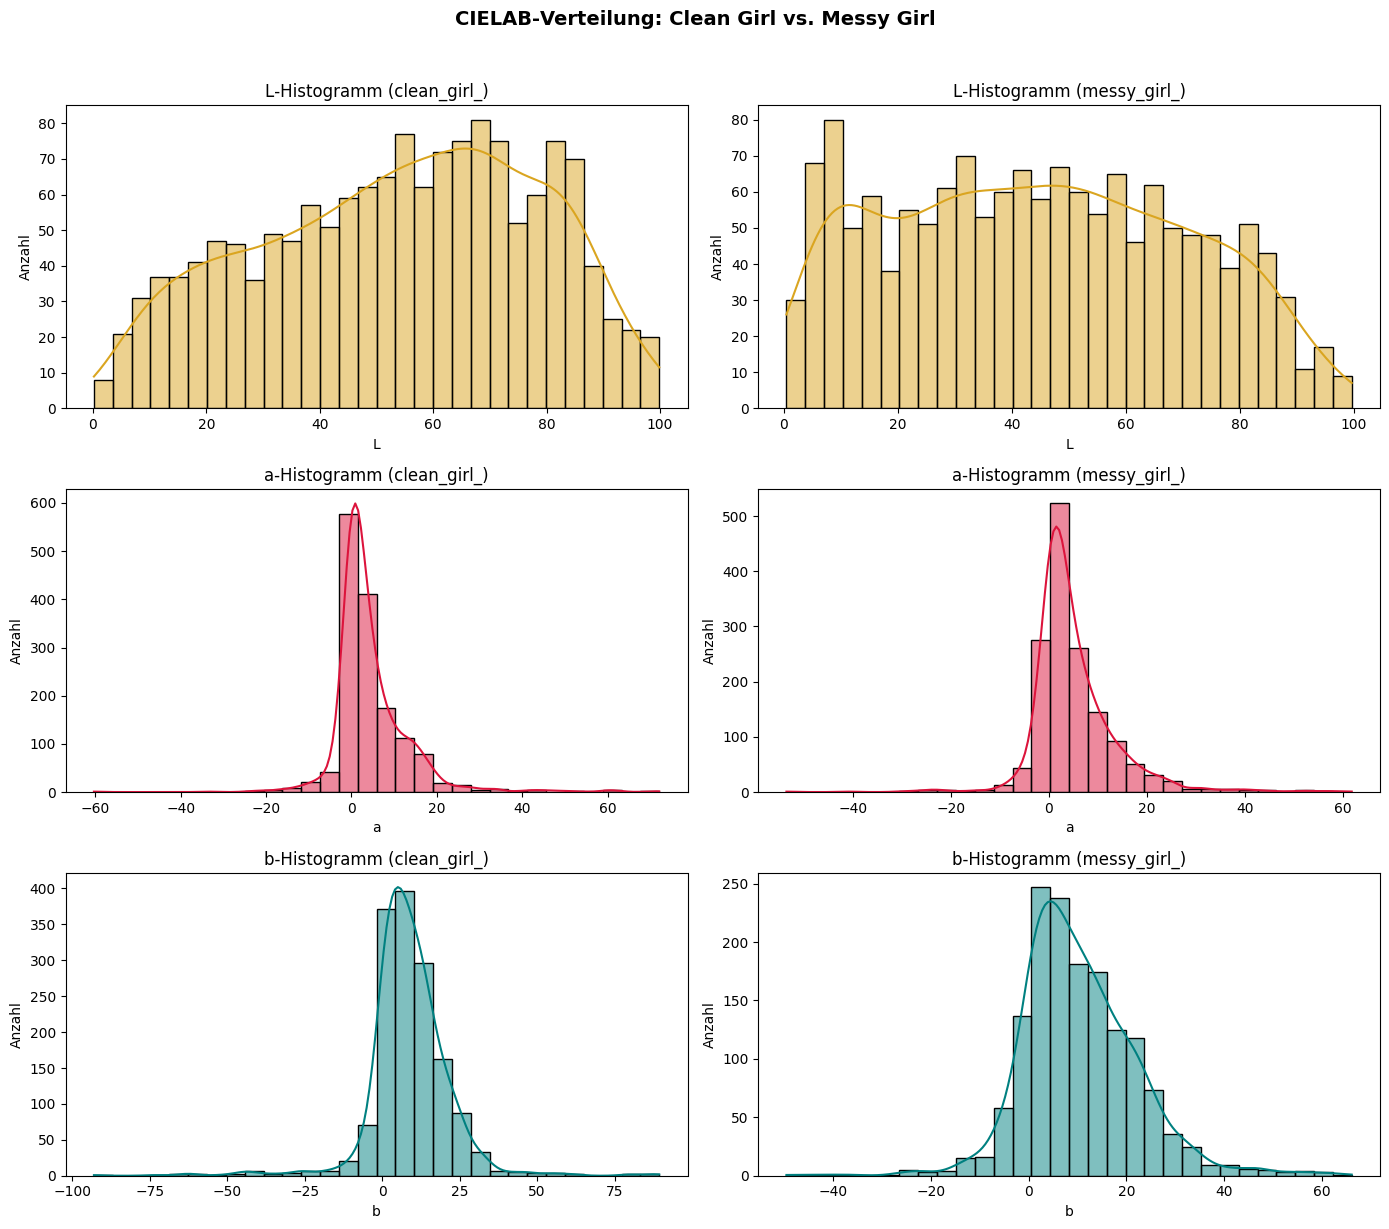

In [ ]:
plot_lab_histograms_compared(palette_df)

KDE-Heatmap

In [ ]:
def plot_ab_kde(palette_df, trend_name):
    subset = palette_df[palette_df["trend"] == trend_name]

    plt.figure(figsize=(6, 5))
    sns.kdeplot(
        x=subset["a"],
        y=subset["b"],
        fill=True,
        cmap="magma",
        thresh=0.05,
        levels=100
    )
    plt.title(f"KDE‑Heatmap im a‑b‑Raum ({trend_name})")
    plt.xlabel("a (grün ↔ rot)")
    plt.ylabel("b (blau ↔ gelb)")
    plt.show()

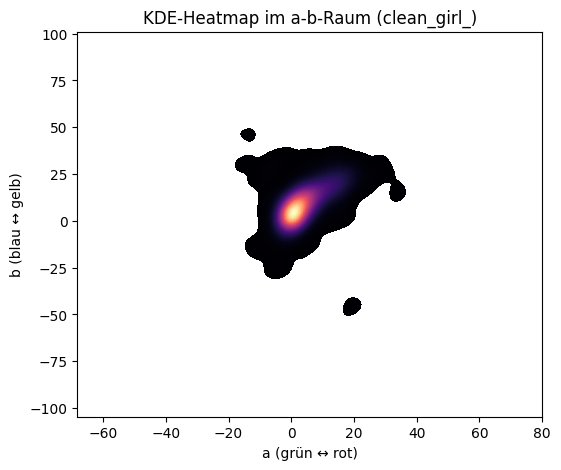

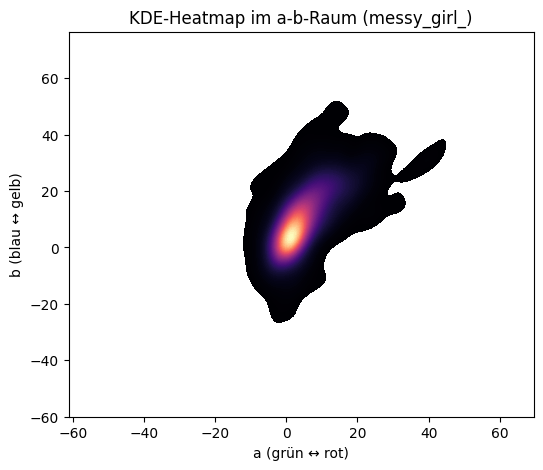

In [ ]:
plot_ab_kde(palette_df, "clean_girl_")
plot_ab_kde(palette_df, "messy_girl_")

Farbdichte

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def plot_lab_3d(palette_df, trend_name):
    subset = palette_df[palette_df["trend"] == trend_name]

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(
        subset["L"], subset["a"], subset["b"],
        c=subset["L"], cmap="viridis", s=10, alpha=0.6
    )

    ax.set_xlabel("L")
    ax.set_ylabel("a")
    ax.set_zlabel("b")
    ax.set_title(f"3D‑LAB‑Farbdichte ({trend_name})")

    plt.show()


In [ ]:
def plot_ab_hexbin(palette_df, trend_name):
    subset = palette_df[palette_df["trend"] == trend_name]

    plt.figure(figsize=(6, 5))
    plt.hexbin(
        subset["a"], subset["b"],
        gridsize=40,
        cmap="inferno",
        mincnt=1
    )
    plt.colorbar(label="Dichte")
    plt.xlabel("a")
    plt.ylabel("b")
    plt.title(f"Hexbin‑Farbdichtekarte (a‑b) – {trend_name}")
    plt.show()


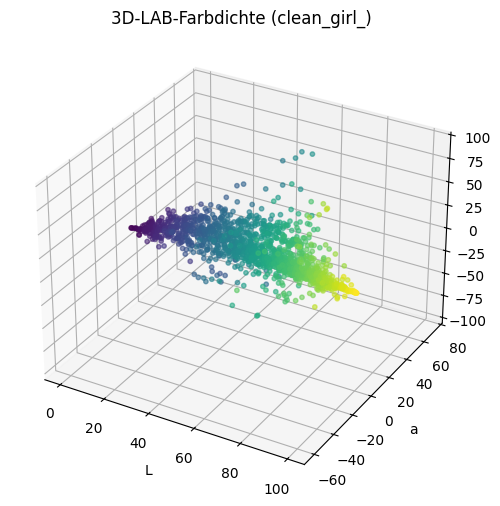

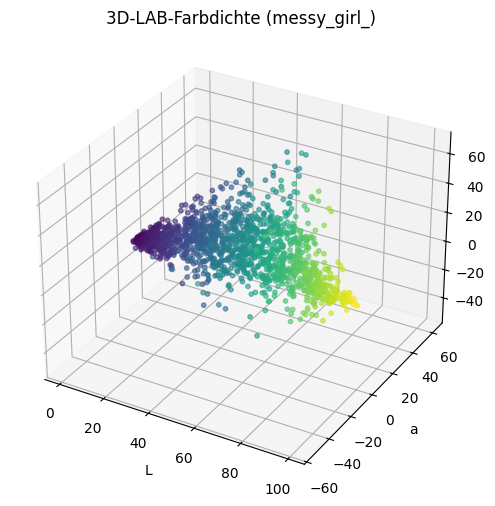

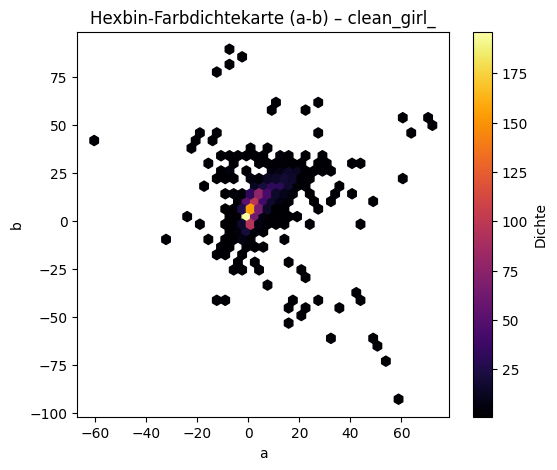

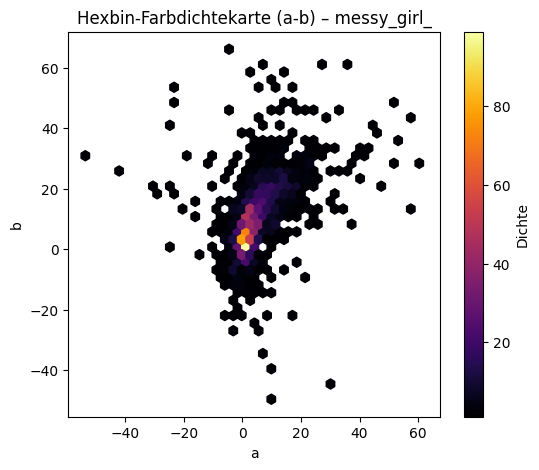

In [ ]:
# 3D-Plot für beide Trends
plot_lab_3d(palette_df, "clean_girl_")
plot_lab_3d(palette_df, "messy_girl_")

# Hexbin für beide Trends
plot_ab_hexbin(palette_df, "clean_girl_")
plot_ab_hexbin(palette_df, "messy_girl_")#